In [1]:
#tis is the part where we import
import numpy as np
import matplotlib.pyplot as plt
import qutip as q
from scipy.special import erfc
from scipy.optimize import brentq


In [ ]:
# ================= 우도 =================
def L_analytic(mu, o):
    """평균 광자수 mu 일 때 관측 o 의 우도.
    o = 0 침묵 -> exp(-mu),  o = 1 클릭 -> 1 - exp(-mu)"""
    return (np.exp(-mu), -np.expm1(-mu))[o]

# ================= 격자 위 정확한 DP =================
def _beta_grid(a, n_s=150):
    """변위 후보. |beta| >= a 이고, s = |beta| - a 를 0 부터 기하적으로 배치.
    s = 0 이 완전 nulling 이라 큰 alpha 에서 이 점이 격자에 반드시 있어야 함."""
    s = np.concatenate([[0.0], np.geomspace(1e-9, 2.5, n_s)])
    return np.concatenate([-(a + s), (a + s)])


def dolinar_error_v1(alpha, N, n_lam=601, n_s=150, return_policy=False):
    """backward induction 으로 오류확률을 직접 계산.
    V_k(lam) = k 슬롯 남았을 때 도달 가능한 최소 오류확률."""
    if alpha <= 0:
        return (0.5, None) if return_policy else 0.5
    a = alpha / np.sqrt(N)
    lam_max = max(12.0, 6.0 * alpha ** 2 + 12.0)
    lam = np.linspace(-lam_max, lam_max, n_lam)
    p = 1.0 / (1.0 + np.exp(-lam))
    V = np.minimum(p, 1 - p)                       # k = 0: 그냥 찍기
    beta = _beta_grid(a, n_s)[None, :]
    P, LAM = p[:, None], lam[:, None]
    mu_p = (a + beta) ** 2 + 1e-300
    mu_m = (-a + beta) ** 2 + 1e-300
    policy = []
    for _ in range(N):
        tot = 0.0
        for o in (0, 1):
            L_p = L_analytic(mu_p, o)
            L_m = L_analytic(mu_m, o)
            nxt = LAM + np.log(L_p + 1e-300) - np.log(L_m + 1e-300)
            tot = tot + (P * L_p + (1 - P) * L_m) * np.interp(nxt, lam, V)
        j = tot.argmin(axis=1)
        V = tot[np.arange(n_lam), j]
        policy.append(beta[0, j])                  # k 슬롯 남았을 때의 최적 beta
    pe = float(np.interp(0.0, lam, V))
    return (pe, (lam, policy)) if return_policy else pe



In [12]:
# ================= 우도 =================
def L_analytic(mu, o):
    """평균 광자수 mu 일 때 관측 o 의 우도.
    o = 0 침묵 -> exp(-mu),  o = 1 클릭 -> 1 - exp(-mu)"""
    return (np.exp(-mu), -np.expm1(-mu))[o]

# ================= 격자 위 정확한 DP =================
def _beta_grid(a, n_s=150):
    """변위 후보. |beta| >= a 이고, s = |beta| - a 를 0 부터 기하적으로 배치.
    s = 0 이 완전 nulling 이라 큰 alpha 에서 이 점이 격자에 반드시 있어야 함."""
    s = np.concatenate([[0.0], np.geomspace(1e-9, 2.5, n_s)])
    return np.concatenate([-(a + s), (a + s)])

def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def _lam_grid(alpha, n_lam=601):
    """믿음 축. lam_max 는 큰 alpha 에서 확신이 세지는 걸 덮을 만큼."""
    lam_max = max(12.0, 6.0 * alpha ** 2 + 12.0)
    return np.linspace(-lam_max, lam_max, n_lam)


def dolinar_update(V, lam, a, beta):
    """벨만 1스텝.  V = V_{k-1} 을 받아 (V_k, 그때의 최적 beta(lam)) 를 돌려줌.

        V_k(lam) = min_beta  sum_o  P(o) * V_{k-1}(lam')
        P(o)  = p L+ + (1-p) L-          그 관측이 나올 예측확률
        lam'  = lam + log L+ - log L-    베이즈 갱신
    """
    p = _sigmoid(lam)
    P, LAM = p[:, None], lam[:, None]          # 믿음 축  (n_lam, 1)
    B = beta[None, :]                          # 제어 축  (1, n_beta)
    mu_p = ( a + B) ** 2 + 1e-300
    mu_m = (-a + B) ** 2 + 1e-300

    tot = 0.0                                  # (n_lam, n_beta) 표
    for o in (0, 1):
        L_p = L_analytic(mu_p, o)
        L_m = L_analytic(mu_m, o)
        nxt = LAM + np.log(L_p + 1e-300) - np.log(L_m + 1e-300)
        tot = tot + (P * L_p + (1 - P) * L_m) * np.interp(nxt, lam, V)

    j = tot.argmin(axis=1)                     # 믿음마다 최적 제어를 고름
    return tot[np.arange(lam.size), j], beta[j]


def dolinar_error_v2(alpha, N, n_lam=601, n_s=150, return_policy=False):
    """backward induction 으로 오류확률을 직접 계산.
    V_k(lam) = k 슬롯 남았을 때 도달 가능한 최소 오류확률."""
    if alpha <= 0:
        return (0.5, None) if return_policy else 0.5

    a    = alpha / np.sqrt(N)                  # 슬롯당 진폭 (에너지 보존)
    lam  = _lam_grid(alpha, n_lam)             # 믿음 축
    beta = _beta_grid(a, n_s)                  # 제어 축

    p = _sigmoid(lam)
    V = np.minimum(p, 1 - p)                   # k = 0 : 그냥 찍기
    policy = []
    for _ in range(N):                         # 남은 슬롯 1개 -> N개
        V, beta_star = dolinar_update(V, lam, a, beta)
        policy.append(beta_star)               # policy[k-1] = k 슬롯 남았을 때

    pe = float(np.interp(0.0, lam, V))         # 사전확률 50:50 -> lam = 0
    return (pe, (lam, policy)) if return_policy else pe

In [9]:
def error_ke(N,alpha_ke,beta_ke=None):
    if beta_ke == None:
        beta_ke=alpha_ke
    a_p=q.coherent(N,alpha_ke) #a_p is positive alpha
    a_n=q.coherent(N,-alpha_ke) #a_n is negative alpha
    #displacement operator
    D_beta = q.displace(N, beta_ke)
    a_dp= D_beta*a_p
    a_dn= D_beta*a_n
    p_dp = abs(a_dp.full()[0][0])**2
    p_dn = abs(a_dn.full()[0][0])**2
    
    return p_dp / 2 + (1 - p_dn) / 2
    

def beta_opt(a):
    if a > 3.0:                       # b* - a < 1 ULP, 구분 불가
        return a
    g = lambda b: 4*a*b - np.log((b + a)/(b - a))
    lo = np.nextafter(a, np.inf)      # 표현 가능한 a 바로 다음 수
    return brentq(g, lo, 3*a + 1)


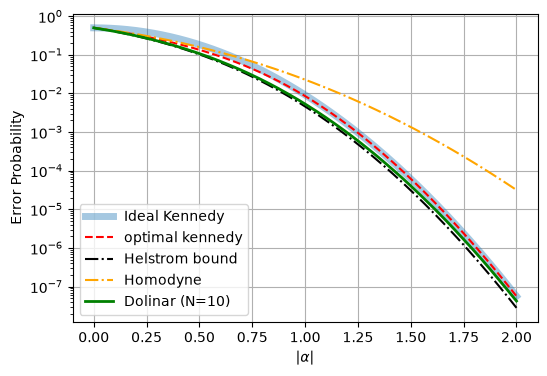

In [10]:
alphas=np.linspace(0,2,200)

# 2. Ideal Kennedy
P_kennedy = 0.5 * np.exp(-4 * np.abs(alphas)**2)

# 3. Helstrom bound
overlap_squared = np.exp(-4 * np.abs(alphas)**2)
P_helstrom = 0.5 * (1 - np.sqrt(1 - overlap_squared))

#optimal kennedy
P_kennedy_opt=[error_ke(30,i,beta_opt(i)) for i in alphas]

#homodyne
P_hom_theory = 0.5 * erfc(np.sqrt(2) * np.abs(alphas))

# --- Simplest Plot Structure ---
fig, ax = plt.subplots(figsize=(6, 4))

# 투명도(alpha=0.4)와 두께(linewidth=5)를 줘서 바탕에 깔아줌
ax.plot(alphas, P_kennedy, label="Ideal Kennedy", linewidth=5, alpha=0.4)

# 그 위에 얇은 점선('--')을 얹어서 두 그래프가 겹쳐서 같이 간다는 걸 증명
ax.plot(alphas,P_kennedy_opt , '--', label="optimal kennedy", color='red')

# 헬스트롬 바운드
ax.plot(alphas, P_helstrom, '-.', label="Helstrom bound", color='black')

#호모다인
ax.plot(alphas, P_hom_theory, '-.', label="Homodyne", color='orange')

#돌리너 리시버
P_dolinar = np.array([dolinar_error(al, 10) for al in alphas])
ax.plot(alphas, P_dolinar, label="Dolinar (N=10)", color='green', lw=2)

ax.set_yscale('log')   # 이거 없으면 세 곡선이 다 붙어 보임
ax.set_xlabel(r"$|\alpha|$")
ax.set_ylabel("Error Probability")
ax.grid(True)
ax.legend()

plt.show()

In [13]:
import time
import numpy as np

alphas = np.linspace(0.1, 2.0, 10)
N_slots = 10

# 첫 번째 함수 (v1) 실행 시간 측정
start_time = time.time()
res_v1 = np.array([dolinar_error_v1(al, N_slots) for al in alphas])
time_v1 = time.time() - start_time

# 두 번째 모듈화된 함수 (v2) 실행 시간 측정
start_time = time.time()
res_v2 = np.array([dolinar_error_v2(al, N_slots) for al in alphas])
time_v2 = time.time() - start_time

print(f"V1 실행 시간: {time_v1:.4f}초")
print(f"V2 실행 시간: {time_v2:.4f}초")
print("두 결과가 완벽히 일치하는가?:", np.allclose(res_v1, res_v2))

V1 실행 시간: 0.4441초
V2 실행 시간: 0.4305초
두 결과가 완벽히 일치하는가?: True


In [9]:
#when you wnat to test L you can use this
def L_qutip(a_signed, beta, o, dim=40):
    """상태를 실제로 만들어 진공 성분을 재는 버전 (검증용)."""
    import qutip as q
    state = q.displace(dim, beta) * q.coherent(dim, a_signed)
    p0 = abs(state.full()[0][0]) ** 2
    return (p0, 1.0 - p0)[o]


def check_likelihood(a, beta, dim=40):
    for s in (+a, -a):
        mu = (s + beta) ** 2
        for o in (0, 1):
            print(f"a={s:+.4f} o={o}  qutip {L_qutip(s, beta, o, dim):.12f}"
                  f"   해석식 {L_analytic(mu, o):.12f}")


In [15]:
#부가적인 공식들
# ================= 몬테카를로 (DP 정책 사용) =================
def run_trial(alpha, N, rng, lam_grid, policy):
    a = alpha / np.sqrt(N)
    true = rng.choice([-1, 1])
    lam = 0.0
    for k in range(N, 0, -1):                      # k = 남은 슬롯 수
        beta = float(np.interp(lam, lam_grid, policy[k - 1]))
        mu_p, mu_m = (a + beta) ** 2, (-a + beta) ** 2
        mu_true = mu_p if true > 0 else mu_m
        o = int(rng.random() > np.exp(-mu_true))   # 측정 (실제론 SPD)
        lam += np.log(L_analytic(mu_p, o) + 1e-300) \
             - np.log(L_analytic(mu_m, o) + 1e-300)
    return (1 if lam > 0 else -1) == true


# ================= 참고: 연속시간 근사 정책 =================
def beta_continuous(lam, a, bmax):
    """beta* = -a/m 을 |beta| <= bmax 로 자른 것. HJB(연속시간) 해라서
    슬롯당 mu 가 작을 때만 유효. 큰 alpha / 작은 N 에서는 DP 를 쓸 것."""
    m = np.clip(np.tanh(lam / 2), -1 + 1e-12, 1 - 1e-12)
    return -bmax if m == 0.0 else -np.sign(m) * min(a / abs(m), bmax)


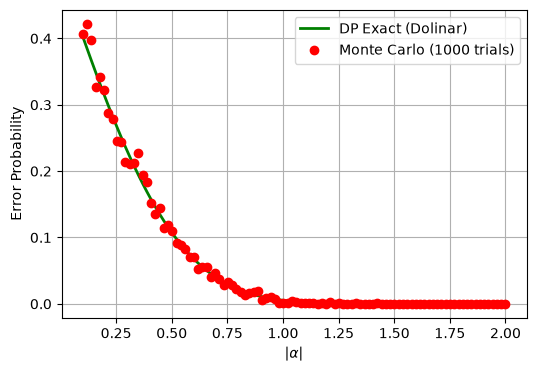

In [18]:
import matplotlib.pyplot as plt

alphas_mc = np.linspace(0.1, 2.0, 100)
N_mc = 10
trials = 1000  # 알파 값 하나당 시뮬레이션 횟수
rng = np.random.default_rng(42)

P_dp_exact = []
P_mc_sim = []

for al in alphas_mc:
    # 1. DP를 이용해 에러 확률과 최적 제어(policy) 추출
    pe, (lam_grid, policy) = dolinar_error_v2(al, N_mc, return_policy=True)
    P_dp_exact.append(pe)
    
    # 2. 추출한 policy를 바탕으로 몬테카를로 런 진행
    errors = 0
    for _ in range(trials):
        # run_trial이 True면 송신 신호와 일치, False면 오류
        success = run_trial(al, N_mc, rng, lam_grid, policy)
        if not success:
            errors += 1
    P_mc_sim.append(errors / trials)

# --- 비교 그래프 그리기 ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(alphas_mc, P_dp_exact, label="DP Exact (Dolinar)", color='green', lw=2)
ax.plot(alphas_mc, P_mc_sim, 'ro', label=f"Monte Carlo ({trials} trials)")

#ax.set_yscale('log')
ax.set_xlabel(r"$|\alpha|$")
ax.set_ylabel("Error Probability")
ax.grid(True)
ax.legend()
plt.show()

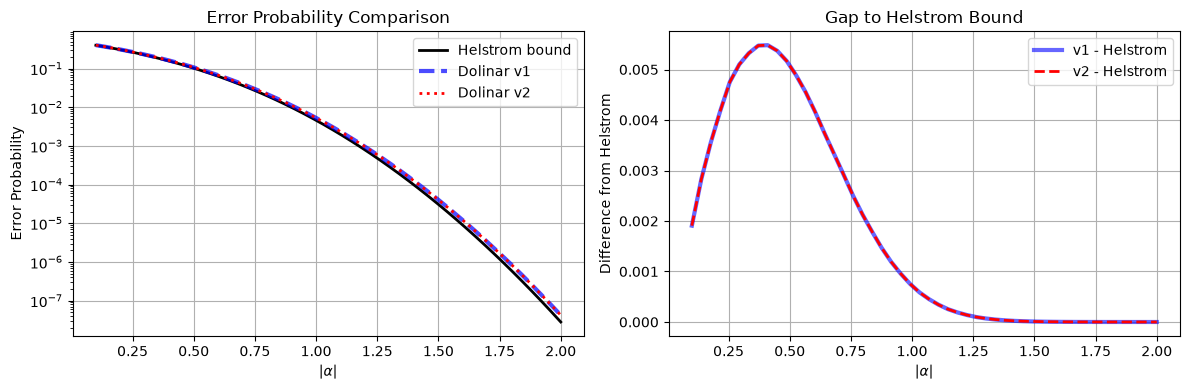

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# 테스트할 알파 범위와 슬롯 수 설정
alphas = np.linspace(0.1, 2.0, 50)
N_slots = 10

# 1. 헬스트롬 바운드 계산 (원본 코드 활용)
overlap_squared = np.exp(-4 * np.abs(alphas)**2) #[cite: 1]
P_helstrom = 0.5 * (1 - np.sqrt(1 - overlap_squared)) #[cite: 1]

# 2. V1과 V2의 돌리너 오류 확률 계산
P_dolinar_v1 = np.array([dolinar_error_v1(al, N_slots) for al in alphas])
P_dolinar_v2 = np.array([dolinar_error_v2(al, N_slots) for al in alphas])

# 3. 헬스트롬 바운드와의 차이(에러 갭) 계산
gap_v1 = P_dolinar_v1 - P_helstrom
gap_v2 = P_dolinar_v2 - P_helstrom

# --- 그래프 그리기 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽: 절대적인 오류 확률 비교 (로그 스케일)
ax1.plot(alphas, P_helstrom, '-k', label="Helstrom bound", lw=2)
ax1.plot(alphas, P_dolinar_v1, '--', label="Dolinar v1", color='blue', alpha=0.7, lw=3)
ax1.plot(alphas, P_dolinar_v2, ':', label="Dolinar v2", color='red', alpha=1.0, lw=2)
ax1.set_yscale('log')
ax1.set_xlabel(r"$|\alpha|$")
ax1.set_ylabel("Error Probability")
ax1.set_title("Error Probability Comparison")
ax1.legend()
ax1.grid(True)

# 오른쪽: 헬스트롬 바운드와의 차이(Gap) 비교 (선형 스케일)
ax2.plot(alphas, gap_v1, '-', label="v1 - Helstrom", color='blue', lw=3, alpha=0.6)
ax2.plot(alphas, gap_v2, '--', label="v2 - Helstrom", color='red', lw=2)
ax2.set_xlabel(r"$|\alpha|$")
ax2.set_ylabel("Difference from Helstrom")
ax2.set_title("Gap to Helstrom Bound")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()